# assessing spinup progress

In [4]:
import os
import sys
from datetime import datetime
from parflow.tools import Run
from parflow.tools.fs import mkdir, cp, get_absolute_path, exists
from parflow.tools.settings import set_working_directory
import numpy as np
import matplotlib.pyplot as plt
from parflow.tools.io import read_pfb,write_pfb, read_clm
import calendar

from parflow import Run
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import rasterio as rst 
import parflow.tools.hydrology as hydro
from parflow.tools.io import read_pfb,write_pfb, read_clm
import parflow.tools.hydrology as hydro
import random
import os
import calendar
import xarray as xr
from matplotlib import colors 


In [ ]:
spinup_runs = np.arange(1, 33, 1)

In [ ]:
"""
Creating the run object from the pdifb and getting grid size and shape. 
Then creating data accessor object ("data = ...")
"""
for run_num in spinup_runs:
    runname = f'spinup_{run_num}.wy2003' # change runname for analysis of each WY2003 simulation of spinup
    path_run = f'~/{runname}/'

    run = Run.from_definition(f'{path_run}{runname}.pfidb')
    run.Solver.CLM.MetFilePath = '~/CW3E_WY2003' # forcing

    data = run.data_accessor # creating data accessor object 
    dx = data.dx
    dy = data.dy
    dz = data.dz
    na,ny,nx = data.shape
    
    porosity= data.computed_porosity
    specific_storage = data.specific_storage
    mask = data.mask
    mask[mask>0]=1 # PF has big # instead of 1 so change to 1 bc more manageable
    surf_mask = mask[-1,:,:] # last element of first axis (always be surface no matter what)

    if run.Mannings.Type == 'PFBFile':
        mannings = np.squeeze(read_pfb(f'{run.Mannings.FileName}'))
    elif run.Mannings.Type == 'Constant':
        mannings = run.Mannings.Geom.domain.Value
    slopex = np.squeeze(data.slope_x)
    slopey = np.squeeze(data.slope_y)

    
    # for converting from LE to ET
    rho_w = 1000 # kg/m3
    hvap   = 2.5104e06    
    nanmask=mask.copy()
    nanmask[nanmask == 0] = 'NaN'
    nanmask[nanmask > 0] = 1
    
    print(path_run)

    # for converting from LE to ET
    rho_w = 1000 # kg/m3
    h_vap   = 2.5104e06

    year = 2003
    if calendar.isleap(year) == False:
    
        num_tsteps = 8760+1
    else: 
        num_tsteps = 8784+1
    # tstep_range = np.arange(0,8760,24)
    # num_tsteps = len(tstep_range)
    
    surface_storage = np.zeros(num_tsteps)
    subsurface_storage = np.zeros(num_tsteps)
    et_sum = np.zeros(num_tsteps)
    precip = np.zeros(num_tsteps)
    overland_out = np.zeros(num_tsteps)
    swe = np.zeros(num_tsteps)
    
    
    # for t in range(num_tsteps):
    for t in range(0,num_tsteps):
        
        # tstep_range[-1]
        data.time = t
        pressure = data.pressure 
        saturation = data.saturation
    
        subsurface_storage[t] = np.sum(hydro.calculate_subsurface_storage(porosity, pressure, saturation, specific_storage, dx,dy,dz, mask=mask),axis=(0,1,2))
        surface_storage[t] = np.sum(hydro.calculate_surface_storage(pressure, dx, dy, mask=mask), axis=(0,1))
        overland_out[t] = hydro.calculate_overland_flow(pressure, slopex, slopey, mannings, dx, dy, flow_method=run.Patch.top.BCPressure.Type,mask=mask)
    
    
                                    
        if t > 0: 
            data.forcing_time = t-1
            precip[t] = np.sum(data.clm_forcing('APCP')[surf_mask==1])#*(3600/1000)*(dx)*(dy) # get rid of unit conversions
            et_sum[t]  = np.sum(data.clm_output('eflx_lh_tot')[surf_mask==1])*(1/rho_w)*(1/h_vap)#*(3600/1000)*(dx)*(dy)
            swe[t]  = np.sum(data.clm_output('swe_out')[surf_mask==1])#*(1/1000)*(dx)*(dy)
        
    
    np.save(f"subsurface_wy2003_{run_num}", subsurface_storage)
    np.save(f"surface_wy2003_{run_num}", surface_storage)
    np.save(f"overland_out_wy2003_{run_num}",  overland_out)
    
    np.save(f"precip_wy2003_{run_num}", precip)
    np.save(f"et_wy2003_{run_num}", et_sum)
    np.save(f"swe_wy2003_{run_num}", swe)

In [5]:
for i in range(1, 33):
    globals()[f"subsurface_storage_{i}"] = np.load(f"subsurface_wy2003_{i}.npy")  # m3
    globals()[f"surface_storage_{i}"] = np.load(f"surface_wy2003_{i}.npy")        # m3

    globals()[f"precip_{i}"] = np.load(f"precip_wy2003_{i}.npy")  # mm/hr, multiply by 3600 s/hr, 1000 mm/m, dx*dy
    globals()[f"et_{i}"] = np.load(f"et_wy2003_{i}.npy")          # m/s, multiply by dx*dy
    globals()[f"swe_{i}"] = np.load(f"swe_wy2003_{i}.npy")        # mm, multiply by dx*dy

In [6]:
# converting so everything is in m3
dx = 1000
dy = 1000
for i in range(1, 33):
    globals()[f"precip_m3_hr_{i}"] = globals()[f"precip_{i}"] * (3600 / 1000) * dx * dy
    globals()[f"et_m3_hr_{i}"] = globals()[f"et_{i}"] * 3600 * dx * dy
    globals()[f"swe_m3_{i}"] = globals()[f"swe_{i}"] * (1 / 1000) * dx * dy

In [9]:
# subsurface storage change normalized by precip - et
for i in range(1, 33):
    globals()[f"sub_norm_{i}"] = (
        globals()[f"subsurface_storage_{i}"][-1]
        - globals()[f"subsurface_storage_{i}"][0]
    ) / (np.sum(globals()[f"precip_m3_hr_{i}"]) - np.sum(globals()[f"et_m3_hr_{i}"]))

    print(f"normalized change in storage, WY2003 run {i} = ",
          globals()[f"sub_norm_{i}"])

    print("")

normalized change in storage, WY2003 run 1 =  0.014451264397010874

normalized change in storage, WY2003 run 2 =  0.030920306362922246

normalized change in storage, WY2003 run 3 =  0.025687433504625906

normalized change in storage, WY2003 run 4 =  0.021886826304922866

normalized change in storage, WY2003 run 5 =  0.019520551160048673

normalized change in storage, WY2003 run 6 =  0.017809027261018236

normalized change in storage, WY2003 run 7 =  0.016545952143511154

normalized change in storage, WY2003 run 8 =  0.01544702400265411

normalized change in storage, WY2003 run 9 =  0.014704000565091774

normalized change in storage, WY2003 run 10 =  0.014161902309441277

normalized change in storage, WY2003 run 11 =  0.01381867904530826

normalized change in storage, WY2003 run 12 =  0.013611885558644832

normalized change in storage, WY2003 run 13 =  0.013266684500935148

normalized change in storage, WY2003 run 14 =  0.013027262137023791

normalized change in storage, WY2003 run 15 =

In [10]:
total_domain_drift_mm = (subsurface_storage_32[-1] - subsurface_storage_31[-1]) / (1883*dx*dy) * 1000
total_domain_drift_mm

1.8581973691019553

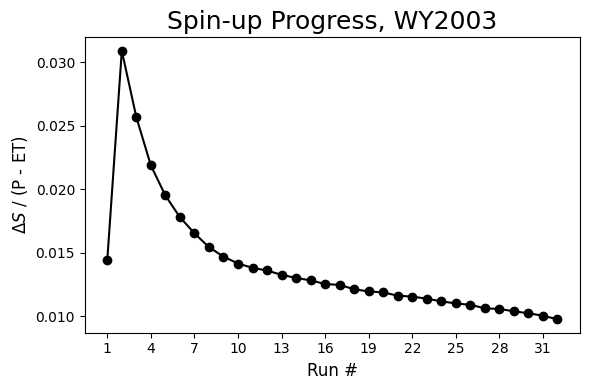

In [15]:
runs = np.arange(1, 33)

storage = np.array([
    globals()[f"sub_norm_{i}"]
    for i in range(1, 33)
])

plt.figure(figsize=(6, 4))
plt.plot(runs, storage, c='black', marker='o')

plt.xlabel('Run #', fontsize=12)
plt.ylabel('$\Delta S$ / (P - ET)', fontsize=12)
plt.xticks(runs)
plt.title('Spin-up Progress, WY2003', fontsize=18)

plt.tight_layout()
plt.xticks(np.arange(1, 33, 3))

plt.show()